In [1]:
import os
from xspec import *
import xspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal
from scipy import optimize, stats
from iminuit import Minuit
from scipy.stats import chi2 as chi2_scipy


Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt

Here I Fit only TM1. First I load the data 

In [2]:
AllData.clear()
path="/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_3deg/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/"
filespectrum=path+"srctoolout_120_SourceSpec_00001.fits"
fileRMF=path+"srctoolout_120_RMF_00001.fits"
fileARF=path+"srctoolout_120_ARF_00001.fits"
#
s1 = Spectrum(filespectrum)
s1.response=fileRMF
s1.response.arf=fileARF

# check the data
AllData.show()

SpectrumOpen = fits.open(filespectrum)['SPECTRUM']
counts = SpectrumOpen.data.field('COUNTS')#
channel = SpectrumOpen.data.field('CHANNEL')#
#exposure = SpectrumOpen.data.getvalue('EXPOSURE')#s
exposure=fits.getval(filespectrum,"exposure", ext=1)
RMFOpen = fits.open(fileRMF)['EBOUNDS']
Emin_data = RMFOpen.data.field('E_MIN')#keV
Emax_data = RMFOpen.data.field('E_MAX')#keV
Eave_data = (Emin_data+Emax_data)/2.
DeltaE_data = Emax_data-Emin_data


 response file  read skipped

1 spectrum  in use
 
Spectral Data File: /Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_3deg/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_120_SourceSpec_00001.fits  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.582e+00 +/- 4.115e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-1024
  Telescope: eROSITA Instrument: TM1  Channel Type: PI
  Exposure Time: 9.345e+04 sec
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Response successfully loaded.
Arf successfully loaded.

1 file 1 spectrum 
Spectrum 1  Spectral Data File: /Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_3deg/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/srctoolout_120_SourceSpec_00001.fits
Net count rate (cts/s) for Spectrum:1  1.582e+00 +/- 4.115e-03
 Assigned to Data Group 1 and Plot Group 1
  Notice

Error: cannot read response file srctoolout_120_RMF_00001.fits


NOW LOAD the Sigma of EROSITA. At the moment I take the FWHM from https://erosita.mpe.mpg.de/edr/eROSITATechnical/calibration.html
Computing \sigma=FWHM/2.355 I find that \sigma ranges from [33,72] eV and E/sigma = [34,139] for E ranging from 1 to 10 keV. 
This is >> sigmav = c/v = 1360 for v=220 km/s.
Larger than intrinsic/Doppler width of astro lines???

In [3]:
vE = np.array([1.,10.])
vFWHM = np.array([0.070,0.165]) #keV
vsigma = vFWHM/(2.355)

Fix the energy of the DM line and select data

In [4]:
# I do not consider eROSITA data outside this range
Eallmin = 0.3
Eallmax = 9.

Eline = 1.0 #0.6893578526708642 #1.31037 #3.434142727659 #7.0504293

sigma = np.interp(Eline,vE,vsigma)
print("Eline ",Eline," sigma ",sigma)
Emin= Eline - 5*sigma
Emax= Eline + 5*sigma
if(Emin<Eallmin):
    Emin=Eallmin
if(Emax>Eallmax):
    Emax=Eallmax
print("Emin ",Emin," Emax ",Emax)
str_range = "**-"+str(round(Emin, 4))+",,"+str(round(Emax, 4))+"-**"
print(str_range)
AllData.ignore(str_range)

Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
energies = np.asarray(Plot.x())
edeltas = np.asarray(Plot.xErr())
rates = np.asarray(Plot.y())
errors = np.asarray(Plot.yErr())
print("***************")
print("Selected values ",np.min(energies)," ",np.max(energies)," Nbins ",len(energies))
print("***************")
channelmin = s1.noticed[0] -1
channelmax = s1.noticed[-1]
DeltaE_ana = DeltaE_data[channelmin:channelmax]
Eave_ana = Eave_data[channelmin:channelmax]
channel_ana = channel[channelmin:channelmax]
counts_ana = counts[channelmin:channelmax]
print("Min Max counts ",np.min(counts_ana)," ",np.max(counts_ana))
#print(s1.noticed[0]," ",s1.noticed[-1])
#counts_ana = counts[172:211]
#print((energies - Eave_ana)/energies)
#print(energies , Eave_ana)
#print((edeltas*2 - DeltaE_ana)/DeltaE_ana)
#print(edeltas*2,DeltaE_ana)

Eline  1.0  sigma  0.029723991507431
Emin  0.851380042462845  Emax  1.148619957537155
**-0.8514,,1.1486-**
Plot command list is now empty
***************
Selected values  0.8562701344490051   1.1407775282859802  Nbins  41
***************
Min Max counts  227   727
   129 channels (1-129) ignored in spectrum #     1
   854 channels (171-1024) ignored in spectrum #     1



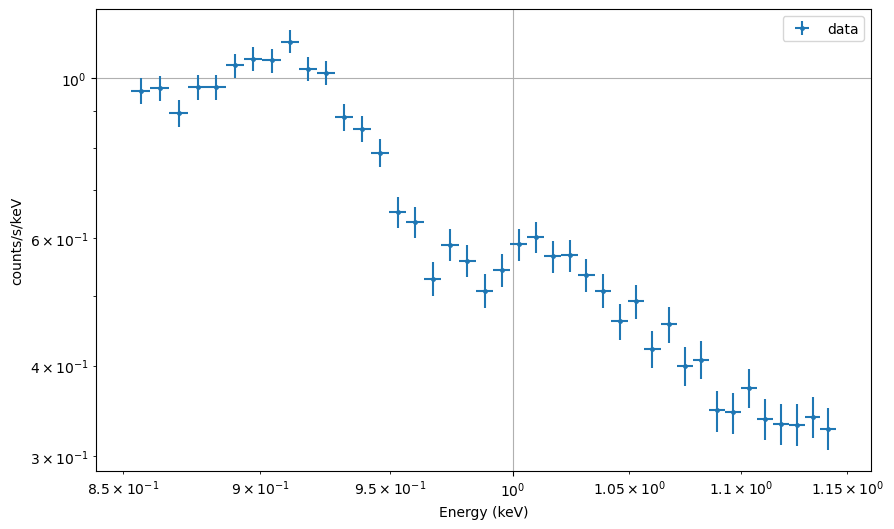

In [5]:
#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Now I consider the Astro and Internal Background lines falling into the energy range +- 7 sigma. At the end I define arrays containing the position of the lines and the min and max values inside which they can fluctuate in the fit


In [6]:
EminL = Eline - 7*sigma
EmaxL = Eline + 7*sigma
if(EminL<Eallmin):
    EminL = Eallmin
if(EmaxL>Eallmax):
    EmaxL = Eallmax

data = np.loadtxt("/Users/marcotaoso/Documents/2024/eROSITA/IB_FWC/IBLines.txt",skiprows=0)
IBenergy = data[:,0]
IBenergymin = data[:,1]
IBenergymax = data[:,2]
data = np.loadtxt("/Users/marcotaoso/Documents/2024/eROSITA/AstroLines/AstroLines.txt",skiprows=0)
Aenergy = data[:,0]
Aenergymin = data[:,1]
Aenergymax = data[:,2]
#print(Aenergy," ",IBenergy)
#print(len(Aenergy)," ",len(IBenergy))
IBidx = np.where( (IBenergy > EminL ) & (IBenergy < EmaxL ) )
Aidx = np.where( (Aenergy > EminL ) & (Aenergy < EmaxL ) )
IBLine = IBenergy[IBidx]
IBLinemin = IBenergymin[IBidx]
IBLinemax = IBenergymax[IBidx]

ALine = Aenergy[Aidx]
#ALinemin = Aenergymin[Aidx]
#ALinemax = Aenergymax[Aidx]
# SET HERE VARIATION OF ASTRO LINE
AstroEl = 0.005;
ALinemin = ALine - AstroEl
ALinemax = ALine + AstroEl

IBn = len(IBLine)
An = len(ALine)
IBAn = IBn + An
IBALine = np.concatenate((IBLine, ALine))
IBALinemin = np.concatenate((IBLinemin, ALinemin))
IBALinemax = np.concatenate((IBLinemax, ALinemax))
idx = np.argsort(IBALine)
IBALine = IBALine[idx]
IBALinemin = IBALinemin[idx]
IBALinemax = IBALinemax[idx]
print("Total lines ",IBAn," IB ",IBn," A ",An)
print(IBALine," IB ",IBLine," A ",ALine)
print(IBALinemin," ",IBALinemax)

Total lines  4  IB  0  A  4
[0.82576263 0.87260693 0.91714752 1.00928032]  IB  []  A  [0.82576263 0.87260693 0.91714752 1.00928032]
[0.82076263 0.86760693 0.91214752 1.00428032]   [0.83076263 0.87760693 0.92214752 1.01428032]


FUNCTIONS TO SET LINES TO ZERO AND FIX THEM OR TO FREE THEM

In [7]:
# GIVES THE array of the lines and set the energy.
# norm fixed to zero and frozen
def FixLineszero(mpoly,IBALine,IBALinemin,IBALinemax):
    for _name in mpoly.componentNames:
    #print(_name)
        if (_name.startswith("gaussian_") and int(_name.split('_')[-1]) <= 30):
            indexl = int(_name.split('_')[-1]) - 5 # 1,2,3 are pl, 4 is DM line
            _comp = mpoly.__getattribute__(_name)
            _comp.LineE.values = [float(IBALine[indexl]), float(IBALine[indexl])*1e-2, float(IBALinemin[indexl]), float(IBALinemin[indexl]), float(IBALinemax[indexl]), float(IBALinemax[indexl])]
            _comp.LineE.frozen = True
            _comp.Sigma.values = 0.0001
            _comp.Sigma.frozen = True
            _comp.norm.values = 0.0
            _comp.norm.frozen = True



# THIS IS IRRELEVANT! I DO NOT need to Free lines since the fit is NOT performed by xspec
# Free only astro which are significant 
#def Freelines(mpoly,indexSign):
#    for _name in mpoly.componentNames:
#        if (_name.startswith("gaussian_") and int(_name.split('_')[-1]) <= 30):
#            indexl = int(_name.split('_')[-1]) - 5 # 1,2,3 are pl, 4 is DM line
#            _comp = mpoly.__getattribute__(_name)
#            if int(_name.split('_')[-1]) in indexSign:
#                _comp.norm.frozen = False
#                _comp.LineE.frozen = False
#            else:
#                _comp.norm.values = 0.0
#                _comp.norm.frozen = True
#                _comp.LineE.frozen = True

DEFINE THE MODEL

In [8]:
# load the model into XSPEC
Xset.chatter = 0

baseM = "powerlaw+powerlaw+powerlaw+gaussian"
linesM = ""
for i in range(0,IBAn):
    linesM= linesM+"+gaussian"
finalM = baseM + linesM
print("Final Model ",finalM)
AllModels.clear()
mpoly = Model(finalM,"mpoly",1)

# COMPUTE norm of the line to hit data
# to have an idea of a sensible normalization
arf1test = fits.open(fileARF)['SPECRESP']
arf1ELOW = arf1test.data.field('ENERG_LO')#keV
arf1EHI = arf1test.data.field('ENERG_HI')#keV
arf1Aeff = arf1test.data.field('SPECRESP')#cm2
arf1E = (arf1ELOW + arf1EHI)/2.
Aefftest = np.interp(Eline, arf1E, arf1Aeff)
Ratetest = np.interp(Eline, energies, rates)
normlDMhdata = Ratetest/Aefftest
print("normlDMhdata ",normlDMhdata)

#Power law
mpoly.powerlaw.PhoIndex = 0.
mpoly.powerlaw.PhoIndex.frozen = True
mpoly.powerlaw_2.PhoIndex = 1.
mpoly.powerlaw_2.PhoIndex.frozen = True
mpoly.powerlaw_3.PhoIndex = 2.
mpoly.powerlaw_3.PhoIndex.frozen = True

# SET DM line and freeze
sigmaDM = Eline* 220/3e5 #1e-4
mpoly.gaussian.LineE = Eline
mpoly.gaussian.LineE.frozen = True
mpoly.gaussian.Sigma = sigmaDM
mpoly.gaussian.Sigma.frozen = True
# normalization in photons/cm$^2$/s in the line
mpoly.gaussian.norm = 0.
mpoly.gaussian.norm.frozen = True
print(mpoly.gaussian.LineE.values)

FixLineszero(mpoly,IBALine, IBALinemin, IBALinemax)


#Xset.chatter = 10
#AllModels.show()
#Xset.chatter = 0

Final Model  powerlaw+powerlaw+powerlaw+gaussian+gaussian+gaussian+gaussian+gaussian
normlDMhdata  0.17661566582906718
[1.0, -0.01, 0.0, 0.0, 1000000.0, 1000000.0]


In [9]:
#https://indico.cern.ch/event/833895/contributions/3577808/attachments/1927550/3191336/iminuit_intro.html

#class MTmodel:
#    def __init__(self, model, params, params_name, params_spec, fit):
#        self.model = model
#        self.params = params
#        self.params_name = params_name
#        self.fit = fit
#        self._norm_refs = [getattr(model, name) for name in params_name]

#    def evaluate_folded(self, params):
#        for ref, value in zip(self._norm_refs, params):
            #print(value)
#            ref.norm = value
#        return self.fit.statistic

In [10]:
# CLASS TO DEFINE A FUNCTION TO EVALUATE THE TS specified in fit GIVEN A xspec Model model 
# with paramers value params, name (gaussuian_3, powerlaw,...) params_name and target (norm, LineE,...) params_target
class MTmodel:
    def __init__(self, model, params_name, params_target, fit): #params
        self.model = model
        ##self.params = params
        self.params_name = params_name
        self.params_target = params_target
        self.fit = fit

        # Precompile setters to eliminate getattr/setattr overhead during evaluate_folded
        self._param_setters = [
            self._make_setter(getattr(model, name), attr)
            for name, attr in zip(params_name, params_target)
        ]

    def _make_setter(self, obj, attr):
        # Closure that sets obj.attr = value
        def setter(value, obj=obj, attr=attr):
            setattr(obj, attr, value)
        return setter

    def evaluate_folded(self, params):
        for setter, value in zip(self._param_setters, params):
            setter(value)
        return self.fit.statistic

DEFINE TS CLASS WITH ONLY POWER LAW AS PARAMETERS, FIST TEST

In [11]:
# 
Fit.statMethod = "cstat"
Fit.nIterations=10000
# starting values
startpl = Ratetest/Aefftest *np.pow(Eline,0.)
startpl_2 = Ratetest/Aefftest *np.pow(Eline,1.)
startpl_3 = Ratetest/Aefftest *np.pow(Eline,2.)
params = np.array([startpl, startpl_2,startpl_3])
params_name = ["powerlaw","powerlaw_2","powerlaw_3"]
params_target = ["norm","norm","norm"]
bounds = [(0.,startpl*2.), (0., startpl_2*2.), (0., startpl_3*2.)]
#print(params)
mymodel = MTmodel(model=mpoly,params_name=params_name, params_target=params_target, fit=Fit)

In [12]:
#SIMPLE TESTS OF THE CLASS: I change the input and I check that TS is different the model has updated parameters
#print("start ",params," ",mymodel.evaluate_folded(params)," ")
#Xset.chatter = 10
#AllModels.show()
#Xset.chatter = 0

#paramstest = np.array([0.3, 0.4, 1.])
#print("start ",paramstest," ",mymodel.evaluate_folded(paramstest)," ")
#Xset.chatter = 10
#AllModels.show()
#Xset.chatter = 0

In [13]:
#Fit.statMethod = "cstat"
#Fit.nIterations=10000
#params = np.array([0.3,0.05])
#params_name = ["gaussian","gaussian"]
#params_target = ["norm","LineE"]
#mymodel = MTmodel(model=mpoly,params=params,params_name=params_name, params_target=params_target, fit=Fit)
#print(mymodel.evaluate_folded(params))

In [14]:
#Xset.chatter = 10
#AllModels.show()
#Xset.chatter = 0

In [15]:
# SIMPLE CHECK with just a costant
#mpoly.powerlaw_2.norm = 0.0
#mpoly.powerlaw_2.norm.frozen = True
#mpoly.powerlaw_3.norm = 0.0
#mpoly.powerlaw_3.norm.frozen = True

#Fit.statMethod = "cstat"
#Fit.nIterations=10000
# starting values
#startpl = Ratetest/Aefftest *np.pow(Eline,0.)
#params = np.array([startpl])
#params_name = ["powerlaw"]
#bounds = [(0.,startpl*2.)]
#mymodel = MTmodel(model=mpoly,params=params,params_name=params_name, fit=Fit)
#print("start ",params," ",mymodel.evaluate_folded(params)," ")

#out = optimize.differential_evolution(mymodel.evaluate_folded, bounds, polish = False, 
#                                      tol = 1e-4, atol = 0, popsize = 600, init = 'sobol',
#                                      maxiter=100000)
#print(out.x, out.fun)

#params = out.x
#m = Minuit(mymodel.evaluate_folded, params)
#m.limits = bounds 
#m.errordef = Minuit.LEAST_SQUARES #i.e. 1
#m.migrad() 
#display(m.fmin, m.params,m.merrors)
#print("Chi2= ",m.fval)
#print(mpoly.powerlaw.norm.values)

FIT DATA WITH POWER LAW MODEL DEFINE ABOVE.
USE FIRST SCIPY AND THEN REFINE WITH MINUIT

In [16]:
params = np.array([startpl, startpl_2,startpl_3])

out = optimize.differential_evolution(mymodel.evaluate_folded, bounds, polish = False, 
                                      tol = 1e-4, atol = 0, popsize = 60, init = 'sobol',
                                      maxiter=100000)

print(out.x, out.fun)

params = out.x
m = Minuit(mymodel.evaluate_folded, params)
m.limits = bounds 
#m.limits = [(0, startpl*2.)]
m.errordef = Minuit.LEAST_SQUARES #i.e. 1
m.migrad() 
display(m.fmin, m.params,m.merrors)
TSpoly = m.fval
print("Chi2= ",TSpoly)
print(mpoly.powerlaw.norm.values)
print(mpoly.powerlaw_2.norm.values)
print(mpoly.powerlaw_3.norm.values)

[3.13082299e-07 1.03180489e-07 1.97989081e-01] 1527.7806347426524


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1528                       │              Nfcn = 40               │
│ EDM = 7.04e-08 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘

,Name,Value,Hesse Error,Minos Error-,Minos Error+,Limit-,Limit+,Fixed
0,x0,0,0.13e-3,,,0,0.353,
1,x1,0,0.26e-3,,,0,0.353,
2,x2,0.1980,0.0015,,,0,0.353,


""
Error
Valid
At Limit
Max FCN
New Min


Chi2=  1527.7777722409573
[2.62707838880398e-15, 2.62707838880398e-17, 0.0, 0.0, 1e+20, 1e+24]
[4.9522130734183456e-08, 4.952213073418345e-10, 0.0, 0.0, 1e+20, 1e+24]
[0.19801375686084083, 0.0019801375686084085, 0.0, 0.0, 1e+20, 1e+24]


NOW CONSIDER THE ASTRO MODEL WITH ALL POSSIBLE LINES

In [17]:
# Astro lines to free
starvaluelines = 5 # 1,2,3 are pl, 4 is DM line
# indexSign contains the line you want to consider and starts from 0, e.g. 0,5,7 where 0 corresponds to gaussian_5
indexSign = np.arange(0,IBAn) #gaussian_2, ..
print(indexSign)

[0 1 2 3]


DEFINE initial parameters, bounds of the parameters and their name and target

In [18]:
paramspoly = np.zeros([3])
paramspoly[0] = startpl
paramspoly[1] = startpl_2
paramspoly[2] = startpl_3
boundspoly = np.zeros(shape=(3,2))
boundspoly[0,0] = 0.
boundspoly[0,1] = startpl*3.0
boundspoly[1,0] = 0.
boundspoly[1,1] = startpl_2*3.0
boundspoly[2,0] = 0.
boundspoly[2,1] = startpl_3*3.0
params_name_poly = ["powerlaw","powerlaw_2","powerlaw_3"]
params_target_poly = ["norm","norm","norm"]

nparamsline = 2*len(indexSign) #norm and LineE
paramsline = np.zeros([nparamsline])
boundsline = np.zeros(shape=(nparamsline,2))
params_name_line = []
params_target_line = []
indexline = 0
for i in range(0,len(indexSign)):
    paramsline[indexline] = normlDMhdata*0.01#norm
    boundsline[indexline,0] = 0.0
    boundsline[indexline,1] = normlDMhdata*3.
    paramsline[indexline+1] = IBALine[indexSign[i]] #LineE
    boundsline[indexline+1,0] = IBALinemin[indexSign[i]]
    boundsline[indexline+1,1] = IBALinemax[indexSign[i]]
    name = "gaussian_"+str(indexSign[i]+starvaluelines)
    params_name_line.append(name)#for norm
    params_name_line.append(name)#append again for LineE
    params_target_line.append("norm")
    params_target_line.append("LineE")
    indexline = indexline+2

params = np.concatenate((paramspoly, paramsline))
bounds = np.concatenate((boundspoly, boundsline))
params_name = np.concatenate((params_name_poly, params_name_line))
params_target = np.concatenate((params_target_poly, params_target_line))
print(params)
print(bounds)
print(params_name)
print(params_target)

[0.17661567 0.17661567 0.17661567 0.00176616 0.82576263 0.00176616
 0.87260693 0.00176616 0.91714752 0.00176616 1.00928032]
[[0.         0.529847  ]
 [0.         0.529847  ]
 [0.         0.529847  ]
 [0.         0.529847  ]
 [0.82076263 0.83076263]
 [0.         0.529847  ]
 [0.86760693 0.87760693]
 [0.         0.529847  ]
 [0.91214752 0.92214752]
 [0.         0.529847  ]
 [1.00428032 1.01428032]]
['powerlaw' 'powerlaw_2' 'powerlaw_3' 'gaussian_5' 'gaussian_5'
 'gaussian_6' 'gaussian_6' 'gaussian_7' 'gaussian_7' 'gaussian_8'
 'gaussian_8']
['norm' 'norm' 'norm' 'norm' 'LineE' 'norm' 'LineE' 'norm' 'LineE' 'norm'
 'LineE']


In [56]:
print(IBALine)

[0.82576263 0.87260693 0.91714752 1.00928032]


DEFINE TS CLASS WITH THE RELEVANT PARAMETERS

In [19]:
# 
mymodel = MTmodel(model=mpoly,params_name=params_name,params_target=params_target, fit=Fit)

# AS A SIMPLE CHECK EVALUATE IT AT the initial parameters, then different set and see if Model parameters are updated
#print("start ",params," ",mymodel.evaluate_folded(params)," ")
#Xset.chatter = 10
#AllModels.show()
#Xset.chatter = 0

#paramstest = params
#paramstest[3]=0.0001
#paramstest[3]=2.0
#print("start ",paramstest," ",mymodel.evaluate_folded(paramstest)," ")
#Xset.chatter = 10
#AllModels.show()
#Xset.chatter = 0

NOW PERFORM THE FIT

In [20]:
out = optimize.differential_evolution(mymodel.evaluate_folded, bounds, polish = False, 
                                      tol = 1e-4, atol = 0, popsize = 60, init = 'sobol',
                                     maxiter=100000) #maxiter=100000

print("Scipy")
print(out.x, out.fun)

print("MINUIT")
params = out.x

m = Minuit(mymodel.evaluate_folded, params)
m.limits = bounds 
m.errordef = Minuit.LEAST_SQUARES #i.e. 1
m.migrad() 
display(m.fmin, m.params,m.merrors)
print("Chi2= ",m.fval)
#print(mpoly.powerlaw.norm.values)
#print(mpoly.powerlaw_2.norm.values)
#print(mpoly.powerlaw_3.norm.values)

Scipy
[3.95632040e-06 2.43268758e-02 1.00896485e-01 1.81186990e-02
 8.21378005e-01 5.05410016e-03 8.74069685e-01 1.38475433e-02
 9.16154236e-01 4.45417683e-03 1.00714262e+00] 34.85479221570358
MINUIT


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 34.85                      │              Nfcn = 961              │
│ EDM = 3.34e-07 (Goal: 0.0002)    │            time = 1.8 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED           │       Covariance NOT pos. def.       │
└──────────────────────────────────┴──────────────────────────────────────┘

,Name,Value,Hesse Error,Minos Error-,Minos Error+,Limit-,Limit+,Fixed
0,x0,1.5829e-8,0.0000e-8,,,0,0.53,
1,x1,2.419e-2,0.000e-2,,,0,0.53,
2,x2,1.0105e-1,0.0000e-1,,,0,0.53,
3,x3,1.8123e-2,0.0000e-2,,,0,0.53,
4,x4,8.213e-1,0.000e-1,,,0.821,0.831,
5,x5,5.0527e-3,0.0000e-3,,,0,0.53,
6,x6,8.7407e-1,0.0000e-1,,,0.868,0.878,
7,x7,1.3845e-2,0.0000e-2,,,0,0.53,
8,x8,9.1615e-1,0.0000e-1,,,0.912,0.922,
9,x9,4.4522e-3,0.0000e-3,,,0,0.53,


""
Error
Valid
At Limit
Max FCN
New Min


Chi2=  34.85473040647611


In [21]:
TS_astro = m.fval
params_astro = []
for p in m.params:
    params_astro.append(p.value)

params_astro = np.array(params_astro)
print("TS_astro ",TS_astro," params_astro ",params_astro)

TS_astro  34.85473040647611  params_astro  [1.58289392e-08 2.41904226e-02 1.01054710e-01 1.81234854e-02
 8.21304321e-01 5.05274700e-03 8.74069685e-01 1.38450125e-02
 9.16154236e-01 4.45216137e-03 1.00714261e+00]


In [22]:
print("TS = ",TS_astro,"  TS poly ",TSpoly)

TS =  34.85473040647611   TS poly  1527.7777722409573


In [55]:
dof = len(energies) - m.nfit
print("The chi^2/DOF of the null-model fit is :", TS_astro/(dof))
print("Expected 68% containment for the chi^2/DOF:", np.array(chi2_scipy.interval(0.68,dof))/float(dof))
print("Expected 99% containment for the chi^2/DOF:", np.array(chi2_scipy.interval(0.99,dof))/float(dof))
print("p-value ", 1. - chi2_scipy.cdf(TS_astro,dof))

The chi^2/DOF of the null-model fit is : 1.2018872553957278
Expected 68% containment for the chi^2/DOF: [0.7416375  1.25792745]
Expected 99% containment for the chi^2/DOF: [0.45245341 1.80467648]
p-value  0.2093496439569661


In [23]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 0


Parameters defined:
Model mpoly:powerlaw<1> + powerlaw<2> + powerlaw<3> + gaussian<4> + gaussian<5> + gaussian<6> + gaussian<7> + gaussian<8> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            0.0          frozen
   2    1   powerlaw   norm                1.58289E-08  +/-  0.0          
   3    2   powerlaw   PhoIndex            1.00000      frozen
   4    2   powerlaw   norm                2.41904E-02  +/-  0.0          
   5    3   powerlaw   PhoIndex            2.00000      frozen
   6    3   powerlaw   norm                0.101055     +/-  0.0          
   7    4   gaussian   LineE      keV      1.00000      frozen
   8    4   gaussian   Sigma      keV      7.33333E-04  frozen
   9    4   gaussian   norm                0.0          frozen
  10    5   gaussian   LineE      keV      0.821304     frozen
  11    5   gaussian   Sigma      keV      1.00000E-04  frozen
  12    5   gaussian   norm               

SAVE RESULTS IN A FILE

In [24]:

print("n para tot ",nparamsline+3)
res = []
res.append(Eline)
res.append(m.fval)
res.append(m.nfit)
res.append(len(energies))
res.append(m.valid)
for p in m.params:
    res.append(p.value)
    #print(repr(p))
    #print(p.value)

namefile = "Astro_bf.dat"
np.savetxt(namefile,res,header='fval par Nbins valid par')

n para tot  11


Plot command list is now empty


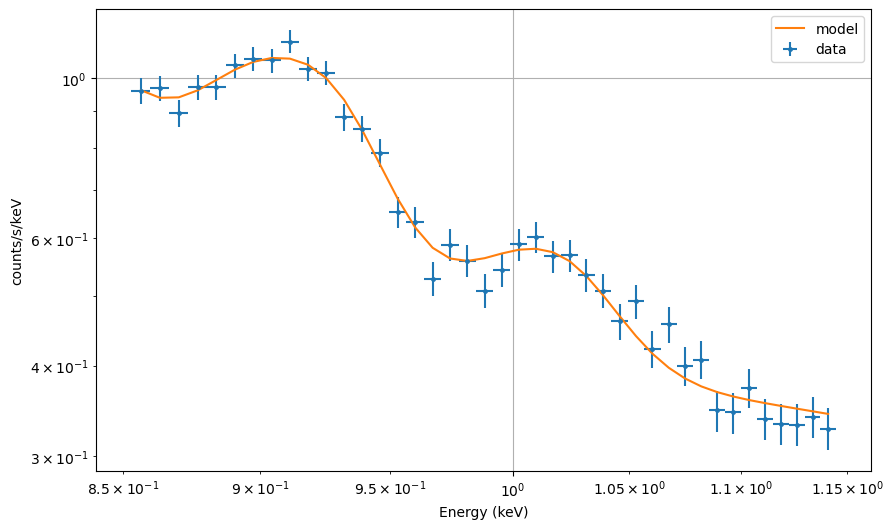

In [25]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
energies = np.asarray(Plot.x())
edeltas = np.asarray(Plot.xErr())
rates = np.asarray(Plot.y())
errors = np.asarray(Plot.yErr())
foldedmodel = np.asarray(Plot.model())

#print("energies ",energies)
#print("foldedmodel ",foldedmodel)

#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
ax.plot(energies, foldedmodel,label='model')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

DEFINE INITIAL PARAMETERS FOR ASTRO + DM

In [26]:

paramsDMline = np.array([normlDMhdata*0.01])
boundsDMline = np.zeros(shape=(1,2))
boundsDMline[0,0] = 0.0
boundsDMline[0,1]= normlDMhdata*3.
params_name_DMline = []
params_target_DMline = []
params_name_DMline.append("gaussian")#for norm
params_target_DMline.append("norm")
    

params_all = np.concatenate((params, paramsDMline))
bounds_all = np.concatenate((bounds, boundsDMline))
params_name_all = np.concatenate((params_name, params_name_DMline))
params_target_all = np.concatenate((params_target, params_target_DMline))
print(params_all)
print(bounds_all)
print(params_name_all)
print(params_target_all)

[3.95632040e-06 2.43268758e-02 1.00896485e-01 1.81186990e-02
 8.21378005e-01 5.05410016e-03 8.74069685e-01 1.38475433e-02
 9.16154236e-01 4.45417683e-03 1.00714262e+00 1.76615666e-03]
[[0.         0.529847  ]
 [0.         0.529847  ]
 [0.         0.529847  ]
 [0.         0.529847  ]
 [0.82076263 0.83076263]
 [0.         0.529847  ]
 [0.86760693 0.87760693]
 [0.         0.529847  ]
 [0.91214752 0.92214752]
 [0.         0.529847  ]
 [1.00428032 1.01428032]
 [0.         0.529847  ]]
['powerlaw' 'powerlaw_2' 'powerlaw_3' 'gaussian_5' 'gaussian_5'
 'gaussian_6' 'gaussian_6' 'gaussian_7' 'gaussian_7' 'gaussian_8'
 'gaussian_8' 'gaussian']
['norm' 'norm' 'norm' 'norm' 'LineE' 'norm' 'LineE' 'norm' 'LineE' 'norm'
 'LineE' 'norm']


In [57]:
print(IBALine)

[0.82576263 0.87260693 0.91714752 1.00928032]


DEFINE TS CLASS WITH THE RELEVANT PARAMETERS

In [27]:
mymodel_all = MTmodel(model=mpoly,params_name=params_name_all,params_target=params_target_all, fit=Fit)

PERFORM THE FIT

In [28]:
#out = optimize.differential_evolution(mymodel_all.evaluate_folded, bounds_all, polish = False, 
#                                      tol = 1e-4, atol = 0, popsize = 60, init = 'sobol',
#                                     maxiter=100) #maxiter=100000

out = optimize.differential_evolution(mymodel_all.evaluate_folded, bounds_all, tol = 1e-4, atol = 0, disp = False, popsize = 60)


print("Scipy")
print(out.x, out.fun)

print("MINUIT")
params_all = out.x

m = Minuit(mymodel_all.evaluate_folded, params_all)
m.limits = bounds_all 
m.errordef = Minuit.LEAST_SQUARES #i.e. 1
m.migrad() 
display(m.fmin, m.params,m.merrors)
print("Chi2= ",m.fval)

TS_all = m.fval
params_all = []
for p in m.params:
    params_all.append(p.value)

params_all = np.array(params_all)
print("TS_astro ",TS_all," params_astro ",params_all)

print("TS all = ",TS_all,"  TS astro ",TS_astro," ",TS_astro-TS_all)

Scipy
[0.         0.02431965 0.10091189 0.01812881 0.82136527 0.00505401
 0.87377662 0.01384696 0.9150435  0.00445326 1.00712688 0.        ] 34.85473403359947
MINUIT


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 34.85                      │              Nfcn = 983              │
│ EDM = 1.12e-06 (Goal: 0.0002)    │            time = 1.9 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│         INVALID Minimum          │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│           Hesse FAILED           │       Covariance NOT pos. def.       │
└──────────────────────────────────┴──────────────────────────────────────┘

,Name,Value,Hesse Error,Minos Error-,Minos Error+,Limit-,Limit+,Fixed
0,x0,5.6913e-9,0.0000e-9,,,0,0.53,
1,x1,2.4318e-2,0.0000e-2,,,0,0.53,
2,x2,1.0091e-1,0.0000e-1,,,0,0.53,
3,x3,1.8129e-2,0.0000e-2,,,0,0.53,
4,x4,8.2123e-1,0.0000e-1,,,0.821,0.831,
5,x5,5.0541e-3,0.0000e-3,,,0,0.53,
6,x6,8.7378e-1,0.0000e-1,,,0.868,0.878,
7,x7,1.3847e-2,0.0000e-2,,,0,0.53,
8,x8,9.1504e-1,0.0000e-1,,,0.912,0.922,
9,x9,4.4532e-3,0.0000e-3,,,0,0.53,


""
Error
Valid
At Limit
Max FCN
New Min


Chi2=  34.854734787271695
TS_astro  34.854734787271695  params_astro  [5.69134927e-09 2.43184053e-02 1.00912211e-01 1.81294632e-02
 8.21226773e-01 5.05407526e-03 8.73776639e-01 1.38472135e-02
 9.15043522e-01 4.45322336e-03 1.00712874e+00 1.38945937e-13]
TS all =  34.854734787271695   TS astro  34.85473040647611   -4.380795587621833e-06


In [29]:
#TS all =  36.13700962060645   TS astro  36.21942540403525   0.08241578342880018

SAVE INFO IN A FILE

In [30]:
res = []
res.append(Eline)
res.append(TS_all)
res.append(m.nfit)
res.append(len(energies))
res.append(m.valid)
res.append(TS_astro - TS_all)
for p in m.params:
    res.append(p.value)
    #print(repr(p))
    #print(p.value)

namefile = "DM_bf.dat"
np.savetxt(namefile,res,header='fval par Nbins valid par')

Plot command list is now empty


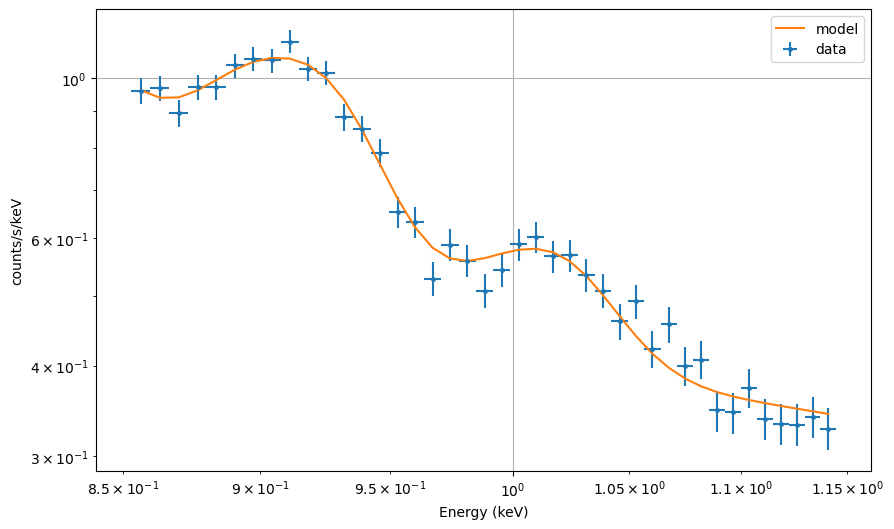

In [31]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
energies = np.asarray(Plot.x())
edeltas = np.asarray(Plot.xErr())
rates = np.asarray(Plot.y())
errors = np.asarray(Plot.yErr())
foldedmodel = np.asarray(Plot.model())

#print("energies ",energies)
#print("foldedmodel ",foldedmodel)

#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
ax.plot(energies, foldedmodel,label='model')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Plot command list is now empty
nAddComps  8


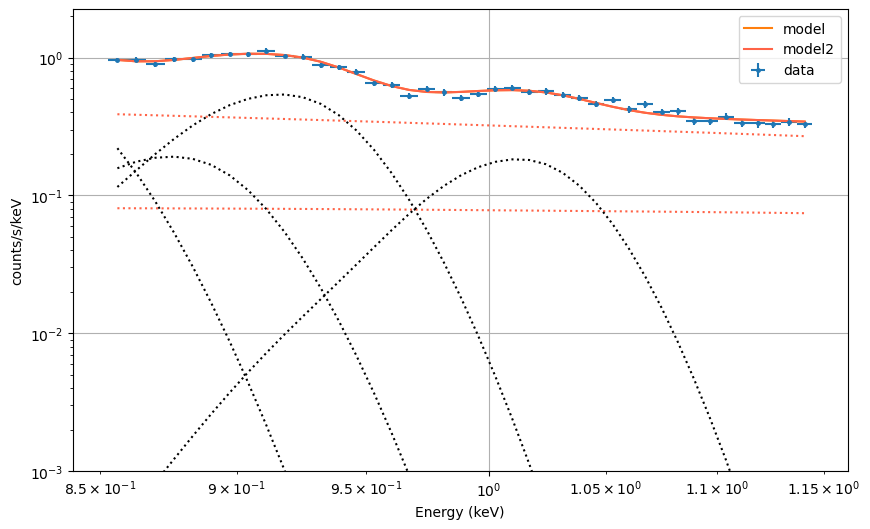

In [32]:
Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")
#ax.clear()
energies = np.asarray(Plot.x())
edeltas = np.asarray(Plot.xErr())
rates = np.asarray(Plot.y())
errors = np.asarray(Plot.yErr())
foldedmodel = np.asarray(Plot.model())
nAddComps = int(Plot.nAddComps())
print("nAddComps ",Plot.nAddComps())
modelcomp = np.zeros((nAddComps, len(energies)))
modelcomptot = np.zeros(len(energies))
for i in range(nAddComps):
    #print(i)
    modelcomp[i] = np.asarray(Plot.addComp(i+1))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
ax.plot(energies, foldedmodel,label='model')
ax.plot(energies, modelcomptot,label='model2',linestyle='-', marker='',color='tomato')
for i in range(0,3):
    #print(i)
    ax.plot(energies, modelcomp[i][:],label='',linestyle=':', marker='',color='tomato')
for i in range(4,nAddComps):
    #print(i)
    ax.plot(energies, modelcomp[i][:],label='',linestyle=':', marker='',color='black')
#DM
ax.plot(energies, modelcomp[3][:],label='',linestyle=':', marker='',color='green')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
Upper = np.max(rates)*2;
ax.set_ylim((0.001,Upper))
ax.grid()
ax.legend()

NOW PROFILE LIKELIHOOD

In [33]:
# Returns chi^2
def chi2(A, return_fit = False):
    
    #profile_bounds = np.copy(problem.bounds)
    #profile_bounds[:, ,sig_index] = A # Fix signal parameter to `A
    
    #m = Minuit.from_array_func(loss, out.x, limit = free_bounds.T, errordef = 1)
    #m.migrad()
    mpoly.gaussian.norm = A
    # The fit is performed using the array params which refers to the case without DM (not varied in the fit) 
    mymodel = MTmodel(model=mpoly,params_name=params_name,params_target=params_target, fit=Fit)
    
    out = optimize.differential_evolution(mymodel.evaluate_folded, bounds, atol = 0, popsize = 60)
    
    params = out.x
    m = Minuit(mymodel.evaluate_folded, params)
    m.limits = bounds 
    m.errordef = Minuit.LEAST_SQUARES #i.e. 1
    m.migrad() 
    
    if return_fit:
        return m.fval, m.np_values()
    
    return m.fval

# All astro parameters fixed to the best-fit of global fit with DM. Input: norm of DM output: TS
def chi2approx(A):
    #mpoly.gaussian.norm = A
    # The TS ie evaluated using the array params_all of best fit value and modifying last value
    # which by convention is DM. I define new array params_inside in order not to modify params_all
    params_inside = params_all
    params_inside[-1] = A
    mymodelprof = MTmodel(model=mpoly,params_name=params_name_all,params_target=params_target_all, fit=Fit)
    #mymodelprof = MTmodel(model=mpoly,params_name=params_name,params_target=params_target, fit=Fit)
    res = mymodelprof.evaluate_folded(params_inside)
    #print(A," ",res)
    return res


def MTroots(vx,vy):
    vroots = []
    for i in range(1,len(vx)):
        #print("vx ",vx[i]," ",vy[i])
        #Check whether sign has changed
        if(vy[i]*vy[i-1]<0.):
            root=(vx[i]*vy[i-1]-vx[i-1]*vy[i])/(vy[i-1]-vy[i])
            #print(vx[i-1]," ",vx[i]," ",vy[i-1]," ",vy[i])
            #print("i ", i," ",root," ")
            vroots.append(root)
    return  vroots

TO UNDERSTAND THE APPROXIMATE BOUND I FIX ALL PARAMETERS TO BEST-FIT MODEL (WITH DM) and I vary DM normalization.
THIS IS MUCH FASTER since I just compute TS without fitting

In [34]:
DMbf = params_all[-1]
start = np.max(np.array([DMbf,normlDMhdata*1e-5]))
end = normlDMhdata
print("start ",start," DM best fit ",DMbf," normlDMhdata ",normlDMhdata)
nDM = 100
profile_range = np.logspace(np.log10(start), np.log10(end), num = nDM)
TS_vals = np.zeros_like(profile_range)
for i, A in enumerate(profile_range):
    TS_vals[i] = chi2approx(A)

#print(TS_vals)

start  1.7661566582906719e-06  DM best fit  1.3894593729518657e-13  normlDMhdata  0.17661566582906718


In [35]:
TSth = 2.71
x=np.log10(profile_range)
y = TS_vals - TS_all - TSth
vroots = np.pow(10.,MTroots(x,y))
bound_approx = 0
if(len(vroots)>0):
    bound_approx=np.max(vroots)
else:
    bound_approx=0.
print("vroots ",vroots)
print("bound_approx ",bound_approx," start ",start," DMbf ",DMbf," normlDMhdata ",normlDMhdata)

vroots  [0.00032268]
bound  0.00032268124418016666  start  1.7661566582906719e-06  DMbf  1.3894593729518657e-13  normlDMhdata  0.17661566582906718


USE INFO ABOVE TO profile properly

In [36]:
# profiling range. I hope that 3 orders of magnitude around the bound_approx is enough.
start = bound_approx/10.
end = bound_approx*100
nDM = 10
profile_range = np.logspace(np.log10(start), np.log10(end), num = nDM)
TS_vals = np.zeros_like(profile_range)

for i, A in enumerate(profile_range):
    TS_vals[i] = chi2(A)
    print(i, A, TS_vals[i], TS_vals[i] - TS_all)

0 3.2268124418016664e-05 35.47118520464164 0.616450417369947
1 6.951956662843994e-05 35.11478309149567 0.2600483042239716
2 0.00014977536598029394 35.91928677674008 1.0645519894683844
3 0.00032268124418016666 36.10837013259891 1.2536353453272113
4 0.0006951956662843994 37.726345558124194 2.8716107708524987
5 0.0014977536598029394 41.67707996074245 6.822345173470751
6 0.0032268124418016663 53.267347484386676 18.41261269711498
7 0.0069519566628439946 92.72752145680715 57.87278666953546
8 0.014977536598029395 727.3452940781408 692.4905592908691
9 0.032268124418016665 4334.826236180554 4299.971501393282


In [37]:
print(TS_vals-TS_all)

[6.16450417e-01 2.60048304e-01 1.06455199e+00 1.25363535e+00
 2.87161077e+00 6.82234517e+00 1.84126127e+01 5.78727867e+01
 6.92490559e+02 4.29997150e+03]


In [38]:
#data = np.vstack((profile_range, TS_vals))
#print(data)
data = np.column_stack([profile_range, TS_vals])
print(data)

namefile = "Profile.dat"
np.savetxt(namefile,data)

[[3.22681244e-05 3.54711852e+01]
 [6.95195666e-05 3.51147831e+01]
 [1.49775366e-04 3.59192868e+01]
 [3.22681244e-04 3.61083701e+01]
 [6.95195666e-04 3.77263456e+01]
 [1.49775366e-03 4.16770800e+01]
 [3.22681244e-03 5.32673475e+01]
 [6.95195666e-03 9.27275215e+01]
 [1.49775366e-02 7.27345294e+02]
 [3.22681244e-02 4.33482624e+03]]


In [40]:
x=np.log10(profile_range)
y = TS_vals - TS_all - TSth
vroots = np.pow(10.,MTroots(x,y))
bound = 0
if(len(vroots)>0):
    bound=np.max(vroots)
else:
    bound=0.
print("vroots ",vroots)
print("bound ",bound," bound_approx ",bound_approx)

vroots  [0.00064389]
bound  0.0006438907724371954  bound_approx  0.00032268124418016666


In [39]:
#print(foldedmodel)
#test = mpoly.folded(1)
#print(test)
#print(len(test))

#SpectrumOpen = fits.open(filespectrum)['SPECTRUM']
#counts = SpectrumOpen.data.field('COUNTS')#
#channel = SpectrumOpen.data.field('CHANNEL')#
#exposure=fits.getval(filespectrum,"exposure", ext=1)
#RMFOpen = fits.open(fileRMF)['EBOUNDS']
#Emin = RMFOpen.data.field('E_MIN')#keV
#Emax = RMFOpen.data.field('E_MAX')#keV
#Eave = (Emin+Emax)/2.
#DeltaE = Emax-Emin
#172 channels (1-172) ignored in spectrum #     1
#813 channels (212-1024) ignored in spectrum #     1
#DeltaE_ana = DeltaE[172:211]
#Eave_ana = Eave[172:211]
#channel_ana = channel[172:211]
#counts_ana = counts[172:211]
#print(len(DeltaE_ana))
#print(test/DeltaE_ana) # RATE GIVEN BY PLOT